In [1]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.setrecursionlimit(100000000)

In [5]:
# スペック部分
class spec:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit:
                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            self.all += 1


            if x <= 1/199.9 * 0.5 * 0.48:
                self.kaitensuu = 0
                self.balls += 1120
                self.normal()
            elif x <= 1/199.9 * 0.5 * 0.49:
                self.kaitensuu = 0
                self.balls += 280
                self.rush()
            elif x <= 1/199.9 * 0.5:
                self.kaitensuu = 0
                self.balls += 1120
                self.rush()
            if x <= 1/199.9:
                self.kaitensuu = 0
                self.balls += 280
                self.normal()

    def rush(self):
        p = random.random()
        if p <= 0.8:
            furiwake = random.random()
            if furiwake <= 0.1:
                self.rush()
            elif furiwake <= 0.5:
                self.balls += 1400
                self.rush()
            elif furiwake <= 0.83:
                self.balls += 2800
                self.rush()
            elif furiwake <= 0.97:
                self.balls += 4200
                self.rush()
            else:
                self.balls += 5600
                self.rush()

        else:
            self.normal()


In [6]:
result = []
for i in tqdm(range(100000)):
    instance = spec(0, 0, 0, 17.2, 2000) # 初期化
    balls = instance.normal()
    result.append(balls)


100%|██████████| 100000/100000 [00:18<00:00, 5504.62it/s]


平均収支:  2745.414474418534
標準偏差:  23902.45119580378
最大値:  208635.6976744336
最小値:  -28804.30232558188
5%点:  -24604.30232558159
95%点:  49315.69767441863


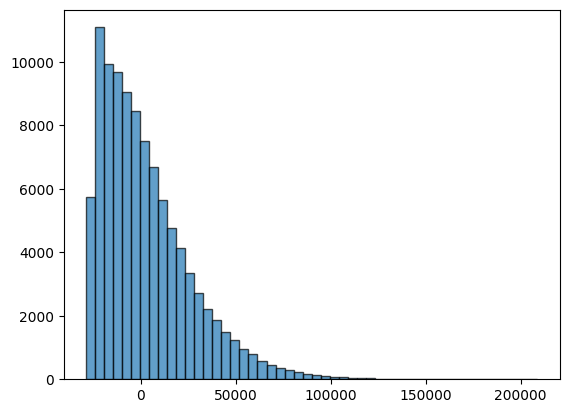

In [7]:
print("平均収支: ", np.mean(result))
print("標準偏差: ", np.std(result))
print("最大値: ", np.max(result))
print("最小値: ", np.min(result))
print("5%点: ", np.percentile(result, 5))
print("95%点: ", np.percentile(result, 95))
plt.hist(np.array(result), bins=50, edgecolor='black', alpha=0.7)
plt.show()